# Lab 2: Classification Using KNN and RNN Algorithms

**Student:** Gyan Bahadur Tamang  
**Course:** MSCS 634 — Big Data and Data Mining  
**Assignment:** Lab 2  

This notebook compares K-Nearest Neighbors (KNN) and Radius Neighbors (RNN) classifiers on scikit-learn's Wine Dataset.

## Environment Setup

Run this cell first. If packages are newly installed, restart the kernel when prompted and then choose **Run All**.

In [15]:
%pip install -q pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 1: Load and Prepare the Dataset

The Wine Dataset contains 178 observations, 13 continuous chemical measurements, and three target classes. A stratified split preserves class proportions in the 80% training and 20% testing sets.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

print('Dataset shape:', X.shape)
print('Feature names:', wine.feature_names)
print('Target classes:', wine.target_names)
print('Class distribution:')
print(y.value_counts().sort_index().rename(index=dict(enumerate(wine.target_names))))
display(X.head())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Dataset shape: (178, 13)
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: ['class_0' 'class_1' 'class_2']
Class distribution:
target
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Training shape: (142, 13)
Testing shape: (36, 13)


## Step 2: Implement K-Nearest Neighbors (KNN)

KNN is trained and evaluated for the five required values of k. Accuracy is the fraction of test observations classified correctly.

In [17]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    predictions = knn.predict(X_test)
    knn_accuracies.append(accuracy_score(y_test, predictions))

knn_results = pd.DataFrame({'k': k_values, 'Accuracy': knn_accuracies})
knn_results

,k,Accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


## Step 3: Implement Radius Neighbors (RNN)

RNN is evaluated for all six required radii. `outlier_label='most_frequent'` provides a defined prediction if a test observation has no training neighbor inside a selected radius; this avoids a runtime error while keeping the requested parameter experiment intact.

In [18]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []
for radius in radius_values:
    rnn = RadiusNeighborsClassifier(radius=radius, outlier_label='most_frequent')
    rnn.fit(X_train, y_train)
    predictions = rnn.predict(X_test)
    rnn_accuracies.append(accuracy_score(y_test, predictions))

rnn_results = pd.DataFrame({'Radius': radius_values, 'Accuracy': rnn_accuracies})
rnn_results

,Radius,Accuracy
0,350,0.722222
1,400,0.694444
2,450,0.694444
3,500,0.694444
4,550,0.666667
5,600,0.666667


## Step 4: Visualize and Compare Results

### 1. KNN Accuracy Trend

Accuracy rises from 77.8% at k=1 to 80.6% at k=5, then remains stable through k=21. This suggests that using several neighbors reduces the sensitivity to individual noisy observations, while larger tested values offer no additional benefit.

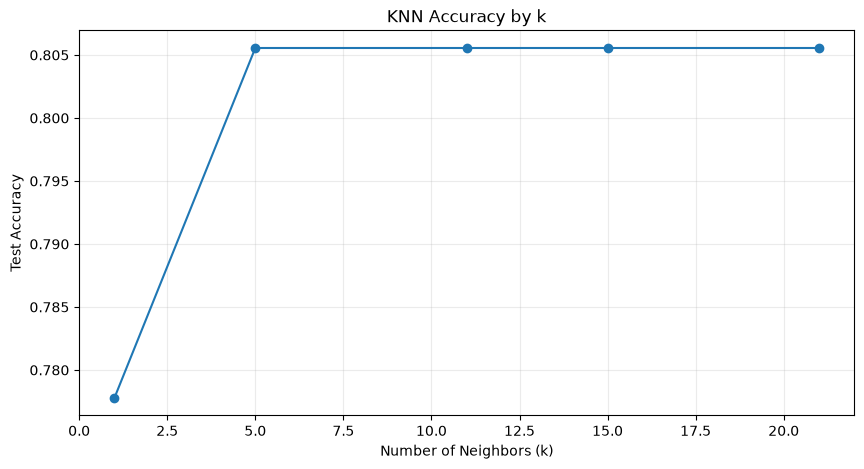

In [19]:
plt.figure(figsize=(10,5))
plt.plot(k_values, knn_accuracies, marker='o')
plt.title('KNN Accuracy by k'); plt.xlabel('Number of Neighbors (k)'); plt.ylabel('Test Accuracy')
plt.grid(alpha=.25); plt.show()

### 2. RNN Accuracy Trend

RNN performs best at radius 350 with 72.2% accuracy. Accuracy generally declines as the radius grows because increasingly distant—and potentially dissimilar—training observations participate in each vote.

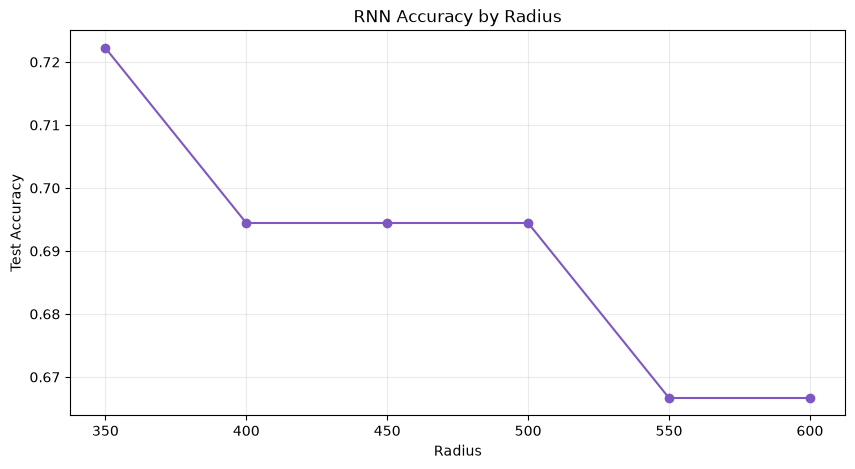

In [20]:
plt.figure(figsize=(10,5))
plt.plot(radius_values, rnn_accuracies, marker='o', color='#7E57C2')
plt.title('RNN Accuracy by Radius'); plt.xlabel('Radius'); plt.ylabel('Test Accuracy')
plt.grid(alpha=.25); plt.show()

### 3. Model Comparison and Observations

The best tested KNN result is **80.6%** (k=5, 11, 15, or 21), compared with **72.2%** for the best tested RNN setting (radius=350). KNN is preferable for this split because it consistently uses a controlled number of nearby observations and achieves higher accuracy. RNN can be preferable when a meaningful distance threshold exists or when local sample density varies: dense regions naturally use more evidence and sparse regions use less. However, RNN is more sensitive to feature scale, radius choice, and observations with no neighbors.

The features are deliberately left in their original units because the assigned RNN radii of 350–600 correspond to those raw distances. Standardization would require a completely different radius range and would answer a different experiment.

In [21]:
best_knn = knn_results.loc[knn_results.Accuracy.idxmax()]
best_rnn = rnn_results.loc[rnn_results.Accuracy.idxmax()]
print(f"Best KNN: k={int(best_knn['k'])}, accuracy={best_knn['Accuracy']:.2%}")
print(f"Best RNN: radius={int(best_rnn['Radius'])}, accuracy={best_rnn['Accuracy']:.2%}")

Best KNN: k=5, accuracy=80.56%
Best RNN: radius=350, accuracy=72.22%


## Conclusion

Parameter selection materially affects neighbor-based classification. KNN improved after k=1 and then plateaued; RNN weakened as radius increased. For this reproducible split and the assigned raw-feature parameter ranges, KNN is the stronger choice. Results are specific to the split and preprocessing, so cross-validation and feature scaling would be useful follow-up experiments.